# varer på salg

I dette programmet vil jeg finne ut om hvordan tilbud påvirker salget til en butikk. 
Jeg skal laget et programm som viser forskjellene i salg og inntekt til butikken i en 30 dagers periode med og uten salg. 


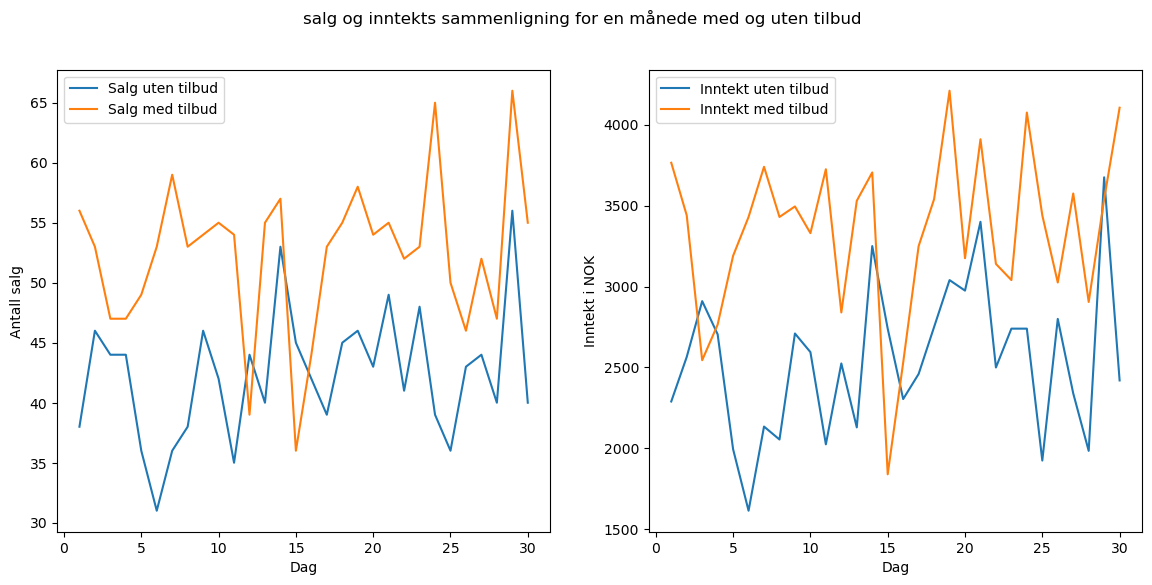

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

#Produkter med pris

produkt = {"pizza": 70, "banan": 20, "sjokolade": 50, "Brød": 45, "kylling": 200}
kjøps_sannsynlighet = {"pizza":0.3, "banan":0.1, "sjokolade":0.08, "Brød":0.3, "kylling":0.05}

#definer tilbudsrate og logistisk modellparameter
tilbudsrate = 0.2
logistisk_m = 10

def logistic_increase(prob, tilbudsrate):
    return prob + (1-prob) /(1+np.exp(-logistisk_m *(tilbudsrate - 0.5)))


#Beregn økte sjanser med tilbud
tilbudssjanse = {produkt: logistic_increase(prob,tilbudsrate) for produkt, prob in kjøps_sannsynlighet.items()}

#simuler en dag

def simuler_dag(produkter, sannsynligheter, kunder): 
    totale_salg = 0
    total_inntekt = 0

    for _ in range(kunder):
        budsjett = random.gauss(500,100)
        for produkt, pris in produkter.items():
            if random.random() <sannsynligheter[produkt] and budsjett >= pris:
                totale_salg += 1
                total_inntekt += pris
                budsjett -= pris
                
    return totale_salg, total_inntekt


#Simuler en måned (30 dager) med og uten tilbud

dager = 30
kunder_pr_dag = 50

salg_uten_tilbud = []
inntekt_uten_tilbud = []
salg_med_tilbud = []
inntekt_med_tilbud = []


for _ in range(dager):
    salg, inntekt = simuler_dag(produkt,kjøps_sannsynlighet, kunder_pr_dag)
    salg_uten_tilbud.append(salg)
    inntekt_uten_tilbud.append(inntekt)
    
    salg, inntekt = simuler_dag(produkt,tilbudssjanse, kunder_pr_dag)
    salg_med_tilbud.append(salg) 
    inntekt_med_tilbud.append(inntekt)

#plot resultatene

dager_resultat = list(range(1, dager+1))

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(dager_resultat, salg_uten_tilbud, label="Salg uten tilbud")
plt.plot(dager_resultat, salg_med_tilbud, label="Salg med tilbud")
plt.xlabel("Dag")
plt.ylabel("Antall salg")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dager_resultat, inntekt_uten_tilbud, label ="Inntekt uten tilbud")
plt.plot(dager_resultat, inntekt_med_tilbud, label ="Inntekt med tilbud")
plt.xlabel("Dag")
plt.ylabel("Inntekt i NOK")
plt.legend()

plt.suptitle("salg og inntekts sammenligning for en månede med og uten tilbud")
plt.show()    

# Resultat og diskusjon

her ser vi en graf som sammenligner salgene til butikken i en 30 dagers periode. Vi ser at salget til butikken gjenvt over høyere enn salgene til butikken hvis det ikke skulle være tilbud. 

etter det ser vi en graf som sammenligner inntektene til butikken i en 30 dagers periode med og uten salg. her ser vi også at det vil lønne seg for butikke å ha salg siden intektene er gjvent over høyere med enn uten tilbud.  
